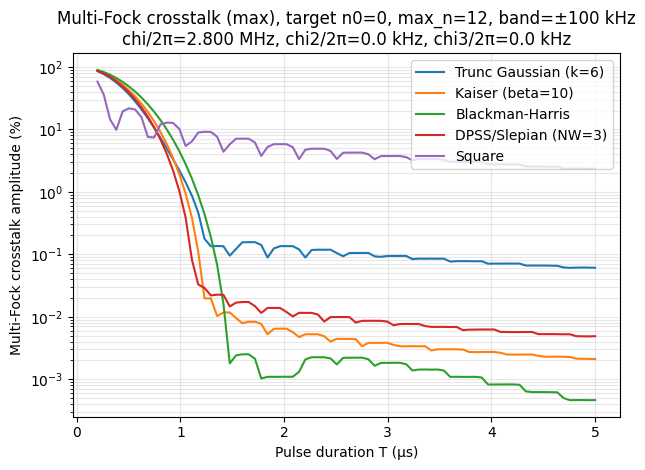

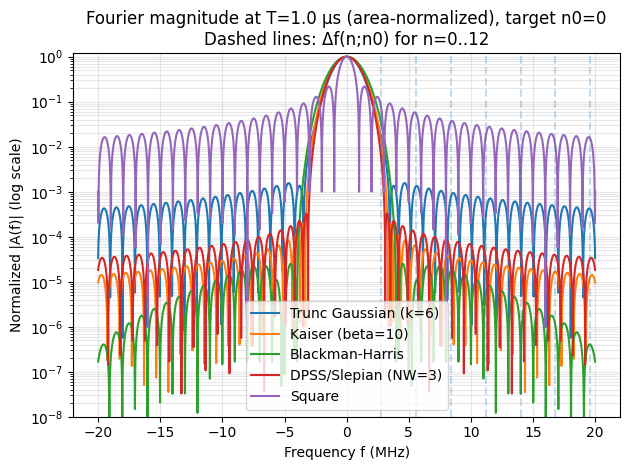

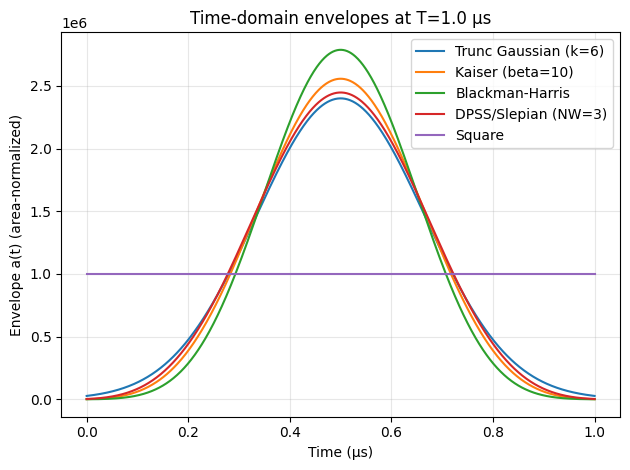

Done.
Tip: If you want a 'population crosstalk' estimate for small leakage r, use P ~ (π r / 2)^2 with r = (percent/100).


In [ ]:
"""
Pulse-shape selectivity simulator (multi-Fock) for Fock-selective qubit pulses.

You told me the number-split frequency offsets (in Hz) are approximately:
    f(n) = chi*n + chi2*n*(n-1) + chi3*n*(n-1)*(n-2)

Goal:
  Compare pulse envelopes by a *multi-Fock* crosstalk metric up to max_n,
  targeting a specific n0 (the addressed Fock level).

We compute, for each pulse duration T:
  A(ω) = ∫ a(t) e^{i ω t} dt
  normalize so A(0)=1 (shape-only comparison)

Then define detunings relative to target n0:
  Δf(n;n0) = f(n) - f(n0)

Multi-Fock crosstalk metrics:
  - metric="max":  max_{n != n0, n<=max_n} max_{δ in [-band, +band]} |A(2π(Δf+δ))| / |A(0)|
  - metric="rms":  sqrt( Σ w_n [ max_{δ} |A(2π(Δf+δ))| / |A(0)| ]^2 )

Plots:
  (1) Crosstalk amplitude (%) vs pulse duration for each pulse shape (log y)
  (2) Fourier magnitude |A(f)| at T0=1 µs for each pulse shape (log y),
      with vertical lines at the relevant Δf(n;n0) detunings for n=0..max_n.

Notes:
  - This is the "Fourier leakage" (rotation-amplitude fraction) metric.
  - For small leakage r, neighbor population error ~ (π r / 2)^2.
"""

import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# User parameters
# -----------------------
# All chi/chi2/chi3 are in Hz (i.e., "over 2π" convention).
chi_hz  = 2.8e6     # χ/2π in Hz
chi2_hz = 0.0        # χ2/2π in Hz (set your value)
chi3_hz = 0.0        # χ3/2π in Hz (set your value)

n0 = 0               # target Fock level you want to address
max_n = 12           # include leakage checks for n=0..max_n

# Robustness band around each detuning (Hz)
band_hz  = 100e3     # e.g. ±100 kHz
band_pts = 11        # number of points in the band (odd recommended)

# Crosstalk metric
metric = "max"       # "max" or "rms"

# If using metric="rms", you can weight n by expected occupancy (optional).
# Set weights=None for uniform weights over n != n0.
weights = None

# Duration sweep (seconds)
T_list = np.linspace(0.2e-6, 5.0e-6, 80)

# Sampling step for numerical integration (seconds)
dt = 1e-9  # 1 ns

# Pulse-shape knobs
gauss_k = 6.0        # truncated Gaussian: T spans k*sigma (k=6 means ±3σ)
kaiser_beta = 10
dpss_NW = 3.0

# Fourier spectrum plot settings
T0 = 1.0e-6          # 1 microsecond
f_max = 20e6         # plot spectrum over ±f_max
n_freq = 5001        # frequency grid points


# -----------------------
# Number-split model: f(n)
# -----------------------
def fock_freq_hz(n: np.ndarray, chi: float, chi2: float = 0.0, chi3: float = 0.0) -> np.ndarray:
    n = np.asarray(n, dtype=int)
    return (
        chi * n
        + chi2 * n * (n - 1)
        + chi3 * n * (n - 1) * (n - 2)
    )

def fock_detunings_hz(n_vals, n0: int, chi: float, chi2: float = 0.0, chi3: float = 0.0) -> np.ndarray:
    n_vals = np.asarray(n_vals, dtype=int)
    return fock_freq_hz(n_vals, chi, chi2, chi3) - float(fock_freq_hz(n0, chi, chi2, chi3))


# -----------------------
# Fourier-area helpers
# -----------------------
def complex_area_omega(a: np.ndarray, t: np.ndarray, omega: float) -> complex:
    """A(ω) = ∫ a(t) e^{i ω t} dt via Riemann sum."""
    return np.sum(a * np.exp(1j * omega * t)) * (t[1] - t[0])

def normalize_area(a: np.ndarray, t: np.ndarray) -> np.ndarray:
    """Scale envelope so A(0)=∫ a(t) dt = 1."""
    A0 = np.sum(a) * (t[1] - t[0])
    if np.isclose(A0, 0.0):
        raise ValueError("Pulse has ~zero area; cannot normalize.")
    return a / A0

def crosstalk_percent_multi_fock(
    a: np.ndarray,
    t: np.ndarray,
    *,
    n0: int,
    max_n: int,
    chi: float,
    chi2: float = 0.0,
    chi3: float = 0.0,
    metric: str = "max",      # "max" or "rms"
    band_hz: float = 0.0,     # if >0, take worst over ±band_hz
    band_pts: int = 11,
    weights: np.ndarray | None = None,  # for RMS: can pass length max_n+1 (for n=0..max_n) or length (#others)
) -> float:
    """
    Return 100 * r where r is multi-Fock leakage amplitude fraction.
    """
    aN = normalize_area(a, t)
    A0 = complex_area_omega(aN, t, 0.0)
    A0_abs = np.abs(A0)

    n_vals = np.arange(0, max_n + 1, dtype=int)
    det_hz = fock_detunings_hz(n_vals, n0=n0, chi=chi, chi2=chi2, chi3=chi3)

    mask = (n_vals != n0)
    n_other = n_vals[mask]
    det_other = det_hz[mask]

    if band_hz and band_hz > 0:
        deltas = np.linspace(-band_hz, +band_hz, int(band_pts))
    else:
        deltas = np.array([0.0])

    # Worst-over-band per n
    r_per_n = np.zeros_like(det_other, dtype=float)
    for i, df in enumerate(det_other):
        # evaluate at df + δ, take max
        vals = []
        for d in deltas:
            omega = 2 * np.pi * (df + d)
            AD = complex_area_omega(aN, t, omega)
            vals.append(np.abs(AD) / A0_abs)
        r_per_n[i] = float(np.max(vals))

    metric = metric.lower().strip()
    if metric == "max":
        r = float(np.max(r_per_n)) if r_per_n.size else 0.0
    elif metric == "rms":
        if weights is None:
            w = np.ones_like(r_per_n) / max(1, r_per_n.size)
        else:
            w = np.asarray(weights, dtype=float)
            # allow weights for n=0..max_n
            if w.shape[0] == (max_n + 1):
                w = w[mask]
            if w.shape != r_per_n.shape:
                raise ValueError("weights shape mismatch for RMS metric")
            w = w / np.sum(w)
        r = float(np.sqrt(np.sum(w * (r_per_n ** 2))))
    else:
        raise ValueError("metric must be 'max' or 'rms'")

    return 100.0 * r


# -----------------------
# Pulse shapes
# -----------------------
def pulse_trunc_gaussian(t: np.ndarray, T: float, k: float) -> np.ndarray:
    """Truncated Gaussian centered in [0,T], with sigma=T/k (so duration spans k*sigma)."""
    tc = 0.5 * T
    sigma = T / k
    return np.exp(-0.5 * ((t - tc) / sigma) ** 2)

def pulse_kaiser(t: np.ndarray, T: float, beta: float) -> np.ndarray:
    """Kaiser window on [0,T]."""
    return np.kaiser(t.size, beta)

def pulse_blackman_harris(t: np.ndarray, T: float) -> np.ndarray:
    """4-term Blackman-Harris window."""
    N = t.size
    n = np.arange(N)
    a0, a1, a2, a3 = 0.35875, 0.48829, 0.14128, 0.01168
    x = 2.0 * np.pi * n / (N - 1)
    return a0 - a1 * np.cos(x) + a2 * np.cos(2 * x) - a3 * np.cos(3 * x)

def pulse_dpss(t: np.ndarray, T: float, NW: float) -> np.ndarray:
    """DPSS/Slepian window (SciPy). Falls back to Kaiser if SciPy unavailable."""
    try:
        from scipy.signal.windows import dpss
        w = dpss(t.size, NW, Kmax=1, sym=True)[0]
        return w
    except Exception:
        return np.kaiser(t.size, 8.0)
        
def pulse_square(t: np.ndarray, T: float) -> np.ndarray:
    """Square pulse on [0,T]."""
    return np.ones_like(t)


# -----------------------
# Sweep: multi-Fock crosstalk vs duration
# -----------------------
results = {
    f"Trunc Gaussian (k={gauss_k:g})": [],
    f"Kaiser (beta={kaiser_beta:g})": [],
    "Blackman-Harris": [],
    f"DPSS/Slepian (NW={dpss_NW:g})": [],
    "Square": [],
}

for T in T_list:
    N = int(np.ceil(T / dt)) + 1
    t = np.linspace(0.0, T, N)

    pulses = {
        f"Trunc Gaussian (k={gauss_k:g})": pulse_trunc_gaussian(t, T, gauss_k),
        f"Kaiser (beta={kaiser_beta:g})": pulse_kaiser(t, T, kaiser_beta),
        "Blackman-Harris": pulse_blackman_harris(t, T),
        f"DPSS/Slepian (NW={dpss_NW:g})": pulse_dpss(t, T, dpss_NW),
        "Square": pulse_square(t, T),
    }

    for label, a in pulses.items():
        xt = crosstalk_percent_multi_fock(
            a, t,
            n0=n0,
            max_n=max_n,
            chi=chi_hz,
            chi2=chi2_hz,
            chi3=chi3_hz,
            metric=metric,
            band_hz=band_hz,
            band_pts=band_pts,
            weights=weights,
        )
        results[label].append(xt)

# Plot: crosstalk vs duration
plt.figure()
x_us = T_list * 1e6
for label, y in results.items():
    plt.plot(x_us, y, label=label)

plt.yscale("log")
plt.xlabel("Pulse duration T (µs)")
plt.ylabel("Multi-Fock crosstalk amplitude (%)")
title = (
    f"Multi-Fock crosstalk ({metric}), target n0={n0}, max_n={max_n}, "
    f"band=±{band_hz/1e3:.0f} kHz\n"
    f"chi/2π={chi_hz/1e6:.3f} MHz, chi2/2π={chi2_hz/1e3:.1f} kHz, chi3/2π={chi3_hz/1e3:.1f} kHz"
)
plt.title(title)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------
# Spectrum plot at T0 = 1 µs
# -----------------------
def spectrum_A_of_f(a: np.ndarray, t: np.ndarray, f_grid: np.ndarray) -> np.ndarray:
    """A(f) = ∫ a(t) e^{i2π f t} dt for all f in f_grid (direct eval)."""
    dt_local = t[1] - t[0]
    phase = np.exp(1j * 2*np.pi * t[:, None] * f_grid[None, :])
    return (a[:, None] * phase).sum(axis=0) * dt_local

N0 = int(np.ceil(T0 / dt)) + 1
t0 = np.linspace(0.0, T0, N0)

pulses0 = {
    f"Trunc Gaussian (k={gauss_k:g})": pulse_trunc_gaussian(t0, T0, gauss_k),
    f"Kaiser (beta={kaiser_beta:g})": pulse_kaiser(t0, T0, kaiser_beta),
    "Blackman-Harris": pulse_blackman_harris(t0, T0),
    f"DPSS/Slepian (NW={dpss_NW:g})": pulse_dpss(t0, T0, dpss_NW),
    "Square": pulse_square(t0, T0),
}
# area-normalize for comparability
pulses0 = {k: normalize_area(v, t0) for k, v in pulses0.items()}

f_grid = np.linspace(-f_max, f_max, n_freq)

spec = {}
for name, a in pulses0.items():
    A = spectrum_A_of_f(a, t0, f_grid)
    mag = np.abs(A)
    # normalize by DC component magnitude (should be 1-ish after area norm)
    spec[name] = mag / np.max(mag)

# detunings relative to target manifold n0 (Hz)
n_vals = np.arange(0, max_n + 1, dtype=int)
det_hz = fock_detunings_hz(n_vals, n0=n0, chi=chi_hz, chi2=chi2_hz, chi3=chi3_hz)

plt.figure()
x_mhz = f_grid / 1e6
for name, mag in spec.items():
    plt.plot(x_mhz, mag, label=name)

# mark the number-split detunings
for n, df in zip(n_vals, det_hz):
    if n == n0:
        continue
    # Only draw if inside plotting range
    if abs(df) <= f_max:
        plt.axvline(df / 1e6, linestyle="--", alpha=0.25)

plt.yscale("log")
plt.ylim(1e-8, 1.2)
plt.xlabel("Frequency f (MHz)")
plt.ylabel("Normalized |A(f)| (log scale)")
plt.title(f"Fourier magnitude at T={T0*1e6:.1f} µs (area-normalized), target n0={n0}\n"
          f"Dashed lines: Δf(n;n0) for n=0..{max_n}")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: time-domain pulses at T0
plt.figure()
x_us0 = t0 * 1e6
for name, a in pulses0.items():
    plt.plot(x_us0, a, label=name)
plt.xlabel("Time (µs)")
plt.ylabel("Envelope a(t) (area-normalized)")
plt.title(f"Time-domain envelopes at T={T0*1e6:.1f} µs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print("Done.")
print("Tip: If you want a 'population crosstalk' estimate for small leakage r, use P ~ (π r / 2)^2 with r = (percent/100).")

### Full optimization

In [6]:
"""
Pulse-shape selectivity simulator (multi-Fock) using *your* waveform generators.

Goal:
  Compare pulse envelopes by a *multi-Fock* crosstalk metric up to max_n,
  targeting a specific n0 (the addressed Fock level).

We compute, for each pulse duration T:
  A(ω) = ∫ z(t) e^{i ω t} dt
  normalize so A(0)=1 (shape-only comparison, handles complex z(t)=I+iQ)

Then define detunings relative to target n0:
  Δf(n;n0) = f(n) - f(n0)

Multi-Fock crosstalk metrics:
  - metric="max": max_{n != n0} max_{δ in [-band,+band]} |A(2π(Δf+δ))|
  - metric="rms": sqrt( Σ w_n [ max_{δ} |A(2π(Δf+δ))| ]^2 )

Plots:
  (1) Crosstalk amplitude (%) vs pulse duration for each pulse shape (log y)
  (2) Fourier magnitude |A(f)| at T0 for each pulse shape (log y),
      with vertical lines at Δf(n;n0) for n=0..max_n.
  (3) Time-domain envelopes at T0.

Notes:
  - This is a "Fourier leakage" metric for *Fock-selective addressing* (number-split detunings).
  - DRAG shapes include Q(t); normalization uses complex area so A(0)=1 exactly.
  - If you want a rough population error estimate for small leakage r:
        P ~ (π r / 2)^2   with r = (percent/100).
"""

import numpy as np
import matplotlib.pyplot as plt


# -----------------------
# Your waveform generators (paste/import yours here)
# -----------------------
# from your_module import (
#     drag_gaussian_pulse_waveforms,
#     kaiser_pulse_waveforms,
#     slepian_pulse_waveforms,
#     drag_cosine_pulse_waveforms,
#     flattop_gaussian_waveform,
#     flattop_cosine_waveform,
#     flattop_tanh_waveform,
#     flattop_blackman_waveform,
# )


# -----------------------
# User parameters
# -----------------------
# All chi/chi2/chi3 are in Hz (i.e., "over 2π" convention).
chi_hz  = 2.8e6
chi2_hz = 0.0
chi3_hz = 0.0

n0 = 0
max_n = 12

# Robustness band around each detuning (Hz)
band_hz  = 100e3
band_pts = 11

metric = "max"     # "max" or "rms"
weights = None     # for RMS, can be None or length (max_n+1) array for n=0..max_n

# Duration sweep (seconds)
T_list = np.linspace(0.2e-6, 5.0e-6, 80)

# Sampling (samples/s)
sampling_rate = 1e9
dt_s = 1.0 / sampling_rate

# Spectrum plot settings
T0 = 1.0e-6
f_max = 20e6
n_freq = 5001

# Pulse-shape knobs (tune these)
gauss_k = 6.0          # for Gaussian DRAG: sigma = length_ns / gauss_k  (k=6 => ~±3σ in window)
drag_alpha = 0.5       # DRAG coefficient (dimensionless in your implementation)
anharm_hz = -200e6     # transmon anharmonicity f21 - f10 in Hz (negative typically)
kaiser_beta = 10.0
dpss_NW = 3.0

# Flattop knobs: choose rise/fall as a fraction of total length
flattop_risefall_frac = 0.2  # e.g., 20% of total length is rise and 20% fall (total 40%)


# -----------------------
# Number-split model: f(n)
# -----------------------
def fock_freq_hz(n: np.ndarray, chi: float, chi2: float = 0.0, chi3: float = 0.0) -> np.ndarray:
    n = np.asarray(n, dtype=int)
    return chi * n + chi2 * n * (n - 1) + chi3 * n * (n - 1) * (n - 2)

def fock_detunings_hz(n_vals, n0: int, chi: float, chi2: float = 0.0, chi3: float = 0.0) -> np.ndarray:
    n_vals = np.asarray(n_vals, dtype=int)
    return fock_freq_hz(n_vals, chi, chi2, chi3) - float(fock_freq_hz(n0, chi, chi2, chi3))


# -----------------------
# Fourier-area helpers (complex envelope)
# -----------------------
def complex_area(z: np.ndarray, dt: float) -> complex:
    """A(0) = ∫ z(t) dt via Riemann sum."""
    return np.sum(z) * dt

def normalize_area_complex(z: np.ndarray, dt: float) -> np.ndarray:
    """Scale envelope so A(0)=1 exactly (complex)."""
    A0 = complex_area(z, dt)
    if np.isclose(A0, 0.0):
        raise ValueError("Pulse has ~zero complex area; cannot normalize.")
    return z / A0

def A_of_omega(z: np.ndarray, t: np.ndarray, omega: np.ndarray) -> np.ndarray:
    """
    A(ω) = ∫ z(t) e^{i ω t} dt for ω array (vectorized).
    z: (N,), t: (N,), omega: (M,)
    Returns: (M,) complex
    """
    # phase: (N,M)
    phase = np.exp(1j * t[:, None] * omega[None, :])
    return (z[:, None] * phase).sum(axis=0) * (t[1] - t[0])

def crosstalk_percent_multi_fock_complex(
    z: np.ndarray,
    t: np.ndarray,
    *,
    n0: int,
    max_n: int,
    chi: float,
    chi2: float = 0.0,
    chi3: float = 0.0,
    metric: str = "max",
    band_hz: float = 0.0,
    band_pts: int = 11,
    weights: np.ndarray | None = None,
) -> float:
    """
    Returns 100 * r where r is a multi-Fock leakage *amplitude fraction*.
    Uses complex envelope z(t)=I+iQ and area-normalizes so A(0)=1.
    """
    dt = t[1] - t[0]
    zN = normalize_area_complex(z, dt)

    n_vals = np.arange(0, max_n + 1, dtype=int)
    det_hz = fock_detunings_hz(n_vals, n0=n0, chi=chi, chi2=chi2, chi3=chi3)

    mask = (n_vals != n0)
    det_other = det_hz[mask]

    if band_hz and band_hz > 0:
        deltas = np.linspace(-band_hz, +band_hz, int(band_pts))
    else:
        deltas = np.array([0.0])

    # Build omega grid for all (n,delta)
    # shape: (n_other, band_pts) -> flatten
    omega_grid = 2 * np.pi * (det_other[:, None] + deltas[None, :])  # rad/s
    omega_flat = omega_grid.reshape(-1)

    Aflat = A_of_omega(zN, t, omega_flat)     # (n_other*band_pts,)
    mag = np.abs(Aflat).reshape(det_other.size, deltas.size)  # (n_other, band_pts)

    # worst-over-band per n
    r_per_n = mag.max(axis=1) if mag.size else np.array([], dtype=float)

    metric = metric.lower().strip()
    if metric == "max":
        r = float(r_per_n.max()) if r_per_n.size else 0.0
    elif metric == "rms":
        if r_per_n.size == 0:
            r = 0.0
        else:
            if weights is None:
                w = np.ones_like(r_per_n) / r_per_n.size
            else:
                w = np.asarray(weights, dtype=float)
                if w.shape[0] == (max_n + 1):
                    w = w[mask]
                if w.shape != r_per_n.shape:
                    raise ValueError("weights shape mismatch for RMS metric")
                w = w / np.sum(w)
            r = float(np.sqrt(np.sum(w * (r_per_n ** 2))))
    else:
        raise ValueError("metric must be 'max' or 'rms'")

    return 100.0 * r


# -----------------------
# Pulse wrappers -> complex envelope z(t)=I+iQ
# -----------------------
def ns_to_len_ns(T_s: float) -> int:
    """Convert seconds to integer ns length consistent with your generators."""
    return int(np.round(T_s * 1e9))

def make_time_axis_from_len(length_ns: int, sampling_rate: float) -> np.ndarray:
    """Match your generators' sampling: t = arange(length, step=1e9/sr) in ns -> convert to seconds."""
    step_ns = 1e9 / sampling_rate
    t_ns = np.arange(length_ns, step=step_ns)  # ns
    return t_ns * 1e-9                         # s

def pulse_drag_gaussian(T_s: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    length_ns = max(2, ns_to_len_ns(T_s))
    sigma_ns = length_ns / gauss_k
    I, Q = drag_gaussian_pulse_waveforms(
        amplitude=1.0,
        length=length_ns,
        sigma=sigma_ns,
        alpha=drag_alpha,
        anharmonicity=anharm_hz,
        detuning=0.0,
        subtracted=True,
        sampling_rate=sampling_rate,
    )
    I = np.asarray(I, dtype=float)
    Q = np.asarray(Q, dtype=float)
    t = make_time_axis_from_len(length_ns, sampling_rate)
    z = I + 1j * Q
    return t, z, I  # return I too for optional plotting

def pulse_drag_cosine(T_s: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    length_ns = max(2, ns_to_len_ns(T_s))
    I, Q = drag_cosine_pulse_waveforms(
        amplitude=1.0,
        length=length_ns,
        alpha=drag_alpha,
        anharmonicity=anharm_hz,
        detuning=0.0,
        sampling_rate=sampling_rate,
    )
    I = np.asarray(I, dtype=float)
    Q = np.asarray(Q, dtype=float)
    t = make_time_axis_from_len(length_ns, sampling_rate)
    z = I + 1j * Q
    return t, z, I

def pulse_kaiser(T_s: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    length_ns = max(2, ns_to_len_ns(T_s))
    I, Q = kaiser_pulse_waveforms(
        amplitude=1.0,
        length=length_ns,
        beta=kaiser_beta,
        detuning=0.0,
        subtracted=True,
        sampling_rate=sampling_rate,
        alpha=0.0,              # set to drag_alpha if you want DRAG-like quadrature on Kaiser
        anharmonicity=anharm_hz,
    )
    I = np.asarray(I, dtype=float)
    Q = np.asarray(Q, dtype=float)
    t = make_time_axis_from_len(length_ns, sampling_rate)
    z = I + 1j * Q
    return t, z, I

def pulse_slepian(T_s: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    length_ns = max(2, ns_to_len_ns(T_s))
    I, Q = slepian_pulse_waveforms(
        amplitude=1.0,
        length=length_ns,
        NW=dpss_NW,
        detuning=0.0,
        subtracted=True,
        sampling_rate=sampling_rate,
        alpha=0.0,              # set to drag_alpha if you want DRAG-like quadrature
        anharmonicity=anharm_hz,
    )
    I = np.asarray(I, dtype=float)
    Q = np.asarray(Q, dtype=float)
    t = make_time_axis_from_len(length_ns, sampling_rate)
    z = I + 1j * Q
    return t, z, I

def pulse_flattop_gauss(T_s: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    length_ns = max(2, ns_to_len_ns(T_s))
    rise_fall = max(1, int(np.round(flattop_risefall_frac * length_ns)))
    flat = max(0, length_ns - 2 * rise_fall)
    env = flattop_gaussian_waveform(
        amplitude=1.0,
        flat_length=flat,
        rise_fall_length=rise_fall,
        return_part="all",
        sampling_rate=sampling_rate,
    )
    I = np.asarray(env, dtype=float)
    Q = np.zeros_like(I)
    # IMPORTANT: flattop helper returns exactly #samples = (flat + 2*rise_fall) at 1ns spacing for 1GHz
    t = np.arange(I.size) * dt_s
    z = I + 1j * Q
    return t, z, I

def pulse_flattop_cos(T_s: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    length_ns = max(2, ns_to_len_ns(T_s))
    rise_fall = max(1, int(np.round(flattop_risefall_frac * length_ns)))
    flat = max(0, length_ns - 2 * rise_fall)
    env = flattop_cosine_waveform(
        amplitude=1.0,
        flat_length=flat,
        rise_fall_length=rise_fall,
        return_part="all",
        sampling_rate=sampling_rate,
    )
    I = np.asarray(env, dtype=float)
    Q = np.zeros_like(I)
    t = np.arange(I.size) * dt_s
    z = I + 1j * Q
    return t, z, I

def pulse_square(T_s: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    length_ns = max(2, ns_to_len_ns(T_s))
    I = np.ones(length_ns, dtype=float)
    Q = np.zeros_like(I)
    t = np.arange(length_ns) * dt_s
    z = I + 1j * Q
    return t, z, I


# Choose which shapes to compare:
PULSES = {
    f"DRAG Gaussian (k={gauss_k:g}, α={drag_alpha:g})": pulse_drag_gaussian,
    f"DRAG Cosine (α={drag_alpha:g})": pulse_drag_cosine,
    f"Kaiser (β={kaiser_beta:g})": pulse_kaiser,
    f"DPSS/Slepian (NW={dpss_NW:g})": pulse_slepian,
    f"Flattop-Gauss (rf={flattop_risefall_frac:g})": pulse_flattop_gauss,
    f"Flattop-Cos (rf={flattop_risefall_frac:g})": pulse_flattop_cos,
    "Square": pulse_square,
}


# -----------------------
# Sweep: multi-Fock crosstalk vs duration
# -----------------------
results = {name: [] for name in PULSES.keys()}

for T in T_list:
    for name, maker in PULSES.items():
        t, z, _ = maker(T)
        xt = crosstalk_percent_multi_fock_complex(
            z, t,
            n0=n0,
            max_n=max_n,
            chi=chi_hz,
            chi2=chi2_hz,
            chi3=chi3_hz,
            metric=metric,
            band_hz=band_hz,
            band_pts=band_pts,
            weights=weights,
        )
        results[name].append(xt)

plt.figure()
x_us = T_list * 1e6
for name, y in results.items():
    plt.plot(x_us, y, label=name)
plt.yscale("log")
plt.xlabel("Pulse duration T (µs)")
plt.ylabel("Multi-Fock crosstalk amplitude (%)")
plt.title(
    f"Multi-Fock crosstalk ({metric}), target n0={n0}, max_n={max_n}, band=±{band_hz/1e3:.0f} kHz\n"
    f"chi={chi_hz/1e6:.3f} MHz, chi2={chi2_hz/1e3:.1f} kHz, chi3={chi3_hz/1e3:.1f} kHz"
)
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


# -----------------------
# Spectrum plot at T0
# -----------------------
def spectrum_A_of_f(z: np.ndarray, t: np.ndarray, f_grid: np.ndarray) -> np.ndarray:
    """A(f)=∫ z(t) e^{i2π f t} dt for all f in f_grid (direct eval, vectorized)."""
    dt = t[1] - t[0]
    zN = normalize_area_complex(z, dt)
    phase = np.exp(1j * 2*np.pi * t[:, None] * f_grid[None, :])
    return (zN[:, None] * phase).sum(axis=0) * dt

f_grid = np.linspace(-f_max, f_max, n_freq)
spec = {}

for name, maker in PULSES.items():
    t0, z0, _ = maker(T0)
    A = spectrum_A_of_f(z0, t0, f_grid)
    mag = np.abs(A)
    # after area-normalization, |A(0)| should be ~1; normalize to peak anyway for plotting
    spec[name] = mag / np.max(mag)

n_vals = np.arange(0, max_n + 1, dtype=int)
det_hz = fock_detunings_hz(n_vals, n0=n0, chi=chi_hz, chi2=chi2_hz, chi3=chi3_hz)

plt.figure()
x_mhz = f_grid / 1e6
for name, mag in spec.items():
    plt.plot(x_mhz, mag, label=name)

for n, df in zip(n_vals, det_hz):
    if n == n0:
        continue
    if abs(df) <= f_max:
        plt.axvline(df / 1e6, linestyle="--", alpha=0.25)

plt.yscale("log")
plt.ylim(1e-8, 1.2)
plt.xlabel("Frequency f (MHz)")
plt.ylabel("Normalized |A(f)| (log scale)")
plt.title(
    f"Fourier magnitude at T={T0*1e6:.1f} µs (area-normalized), target n0={n0}\n"
    f"Dashed lines: Δf(n;n0) for n=0..{max_n}"
)
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


# -----------------------
# Time-domain envelopes at T0 (plot real(I) part after area norm)
# -----------------------
plt.figure()
for name, maker in PULSES.items():
    t0, z0, _ = maker(T0)
    zN = normalize_area_complex(z0, t0[1] - t0[0])
    plt.plot(t0 * 1e6, zN.real, label=name)

plt.xlabel("Time (µs)")
plt.ylabel("Re[z(t)] after area-normalization")
plt.title(f"Time-domain envelopes at T={T0*1e6:.1f} µs")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Done.")
print("Tip: small-leakage population estimate: P ~ (π r / 2)^2 with r = (percent/100).")


NameError: name 'drag_gaussian_pulse_waveforms' is not defined